In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats

pd.options.mode.use_inf_as_na = True

In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [3]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [4]:
# df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') |
#                               (primary_df_interp['Genotype'] == 'Trh')]
# df_WT_Trh_EA = df_WT_Trh[df_WT_Trh['Odour'] == 'EA']
# df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
# df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1P']

# df_Kir_CSD_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKir') 
#                                  | (primary_df_interp['Genotype'] == 'TrhxKir')
#                                  | (primary_df_interp['Genotype'] == 'CSDxKir')
#                                  | (primary_df_interp['Genotype'] == 'WTxCSD')
#                                  | (primary_df_interp['Genotype'] == 'WTxTrh')]
# df_Kir_CSD_Trh = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Starvation'] == 'Fed')
#                               | (df_Kir_CSD_Trh['Starvation'] == '5h')]
# df_Kir_CSD_Trh_EA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'EA']
# df_Kir_CSD_Trh_PA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'PA']
# df_Kir_CSD_Trh_1P = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == '1P']

# df_Kir_CSD = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Genotype'] == 'WTxCSD')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'WTxKir')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'CSDxKir')]
# df_Kir_CSD_EA = df_Kir_CSD[df_Kir_CSD['Odour'] == 'EA']

# df_TNT_uPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixUPN')]

# df_TNT_MPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixMPN')]

# df_TNT_5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
#                             |    (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

# df_TNT_5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
#                             |   (primary_df_interp['Genotype'] == 'TNTix5HT7')]

In [4]:
# WT and Trh dataframes for PA and 1P 
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']



df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']


#Kir crosses for PA and 1P 

df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]



#Concentration validation --> EA

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']

df_KirCross_EA_fed_5h = df_KirCross_EA[(df_KirCross_EA['Starvation'] == 'Fed')
                                      | (df_KirCross_EA['Starvation'] == '5h')]

df_WTxKir_EA_fed_5h = df_KirCross_EA_fed_5h[df_KirCross_EA_fed_5h['Genotype'] == 'WTxKIR']

df_WTxKir_EA_fed_5h_104_105 = df_WTxKir_EA_fed_5h[(df_WTxKir_EA_fed_5h['Concentration'] == '10-4')
                                                    | (df_WTxKir_EA_fed_5h['Concentration'] == '10-5')]



#starvation effects on WT and WTxKir crosses --> EA

df_EA = primary_df_interp[(primary_df_interp['Odour'] == 'EA')]
df_EA_105 = df_EA[(df_EA['Concentration'] == '10-5')]


df_EA_105_starvation = df_EA_105[(df_EA_105['Genotype'] == 'WT')
                             | (df_EA_105['Genotype'] == 'WTxKIR')]


# HT Kir crosses for EA

df_KirCross_HT = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'WTx5HT7')
                                | (primary_df_interp['Genotype'] == 'WTx5HT1A') 
                                | (primary_df_interp['Genotype'] == '5HT7xKIR')
                                | (primary_df_interp['Genotype'] == '5HT1AxKIR')]

df_KirCross_HT_EA = df_KirCross_HT[df_KirCross_HT['Odour'] == 'EA']
df_KirCross_HT_EA_105 = df_KirCross_HT_EA[(df_KirCross_HT_EA['Concentration'] == '10-5')
                                          &((df_KirCross_HT_EA['Starvation'] == 'Fed')
                                            | (df_KirCross_HT_EA['Starvation'] == '5h'))]

df_KirCross_5HT7_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT7')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT7xKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]
df_KirCross_5HT1A_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT1A')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT1AxKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]

# uPN

df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')
                            | (primary_df_interp['Genotype'] == 'TNTexuPN')
                            | (primary_df_interp['Genotype'] == 'TNTixuPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

#mPN

df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

# TNTx5HT7

df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]


# TNTx5HT1A
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

 

In [15]:
# df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA') & (df_TNTxuPN['Concentration'] == '10-5')]

In [17]:
# Defining dataframes for framewise stats:

frame_df = df_TNTx5HT7_EA_105
frame_df = frame_df[frame_df['Frame'] > 300] 
frame_df = frame_df[frame_df['Frame'] < 500] 


# framewise_stats.analyze_two_way_anova(frame_df, plot = True, plot_transform=True)

  Permutation 1 / 10000 (0%)
  Permutation 1001 / 10000 (10%)
  Permutation 2001 / 10000 (20%)
  Permutation 3001 / 10000 (30%)
  Permutation 4001 / 10000 (40%)
  Permutation 5001 / 10000 (50%)
  Permutation 6001 / 10000 (60%)
  Permutation 7001 / 10000 (70%)
  Permutation 8001 / 10000 (80%)
  Permutation 9001 / 10000 (90%)
  Permutation 1 / 10000 (0%)
  Permutation 1001 / 10000 (10%)
  Permutation 2001 / 10000 (20%)
  Permutation 3001 / 10000 (30%)
  Permutation 4001 / 10000 (40%)
  Permutation 5001 / 10000 (50%)
  Permutation 6001 / 10000 (60%)
  Permutation 7001 / 10000 (70%)
  Permutation 8001 / 10000 (80%)
  Permutation 9001 / 10000 (90%)
  Permutation 1 / 10000 (0%)
  Permutation 1001 / 10000 (10%)
  Permutation 2001 / 10000 (20%)
  Permutation 3001 / 10000 (30%)
  Permutation 4001 / 10000 (40%)
  Permutation 5001 / 10000 (50%)
  Permutation 6001 / 10000 (60%)
  Permutation 7001 / 10000 (70%)
  Permutation 8001 / 10000 (80%)
  Permutation 9001 / 10000 (90%)
▶️ Parametric ANOVA ta

c:\Users\hpnhp\anaconda3\Lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


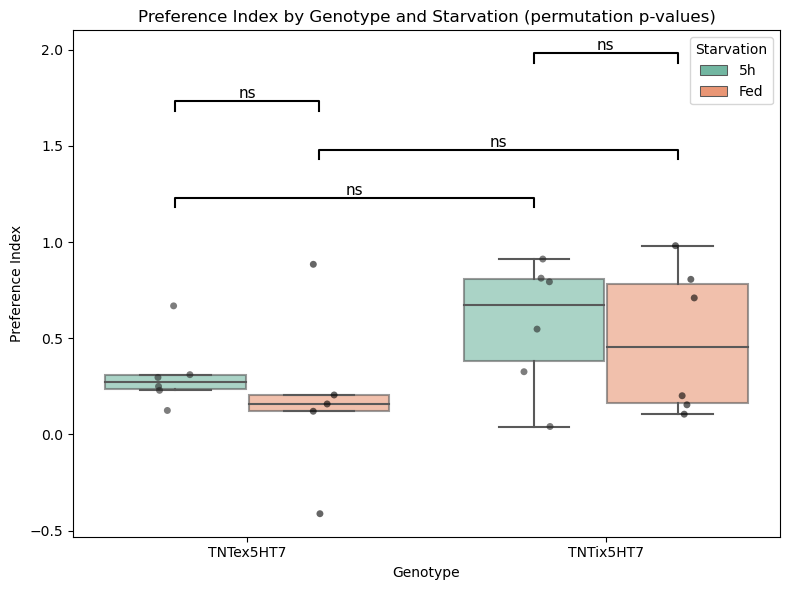

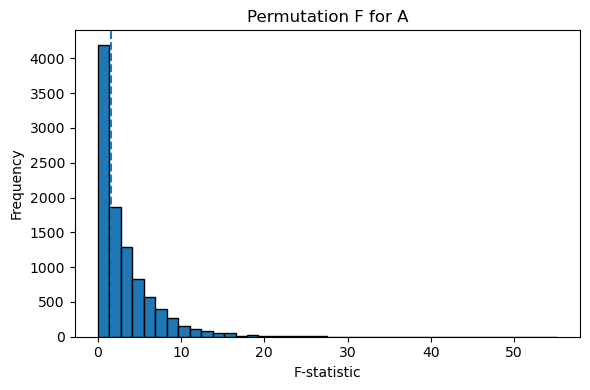

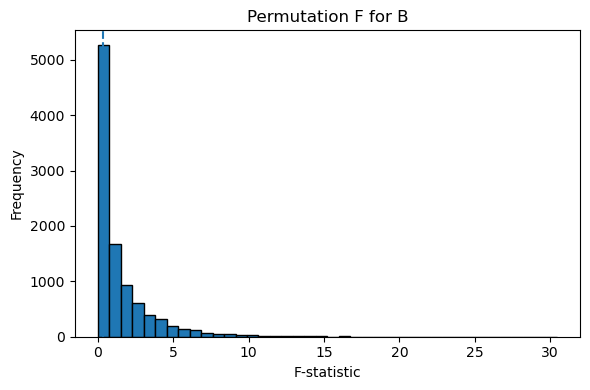

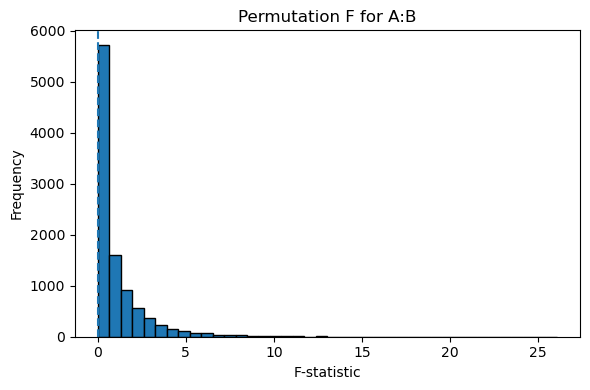

{'anova_table_parametric':                                        sum_sq    df         F    PR(>F)
 Intercept                            0.589144   1.0  4.817221  0.040805
 C(Q("Genotype"))                     0.201150   1.0  1.644736  0.215103
 C(Q("Starvation"))                   0.040559   1.0  0.331639  0.571454
 C(Q("Genotype")):C(Q("Starvation"))  0.002618   1.0  0.021408  0.885213
 Residual                             2.323691  19.0       NaN       NaN,
 'perm_results': {'A': {'F_obs': 1.6447360312852752,
   'p_perm': 0.537046295370463,
   'F_perm': array([3.11759997e+00, 9.89612545e-01, 2.51412501e+00, ...,
          4.83830966e-02, 5.42868364e-05, 7.52623557e+00])},
  'B': {'F_obs': 0.3316393204749363,
   'p_perm': 0.6366363363663634,
   'F_perm': array([0.29243522, 0.01278322, 0.43790878, ..., 0.42664004, 1.06497175,
          1.60452234])},
  'A:B': {'F_obs': 0.021408456810081123,
   'p_perm': 0.8854114588541145,
   'F_perm': array([5.15639538, 0.02581383, 3.72352405, ..., 0

In [18]:
framewise_stats.analyze_two_way_anova_permutation(frame_df, plot=True, plot_perm_dists=True)

c:\Users\hpnhp\anaconda3\Lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:k'` for same effect.
  warnings.warn(msg, FutureWarning)


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

TNTix5HT7_Fed vs. TNTix5HT7_5h: Custom statistical test, P_val:7.118e-01
TNTex5HT7_Fed vs. TNTex5HT7_5h: Custom statistical test, P_val:6.026e-01
TNTex5HT7_5h vs. TNTix5HT7_Fed: Custom statistical test, P_val:3.345e-01
TNTex5HT7_Fed vs. TNTix5HT7_Fed: Custom statistical test, P_val:2.780e-01
TNTex5HT7_5h vs. TNTix5HT7_5h: Custom statistical test, P_val:1.384e-01
TNTex5HT7_Fed vs. TNTix5HT7_5h: Custom statistical test, P_val:1.670e-01


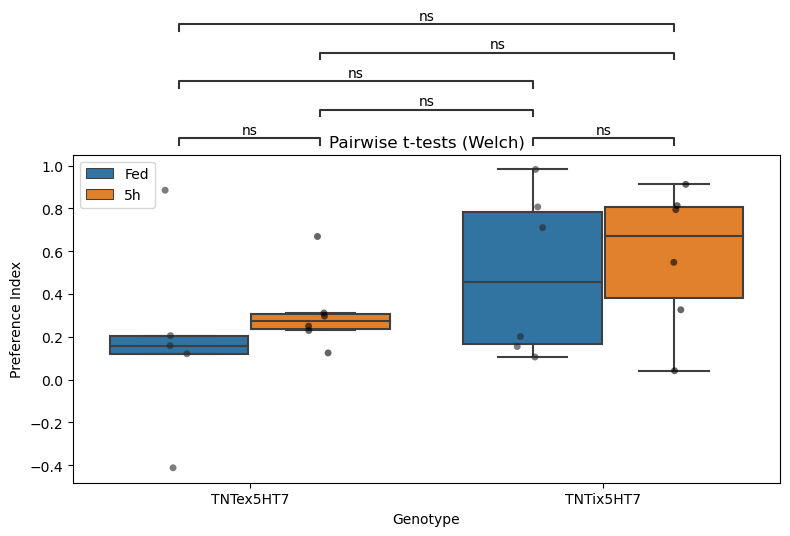

,group1,group2,t,pval
0,"(TNTex5HT7, Fed)","(TNTix5HT7, Fed)",-1.165544,0.278002
1,"(TNTex5HT7, Fed)","(TNTex5HT7, 5h)",-0.554744,0.602592
2,"(TNTex5HT7, Fed)","(TNTix5HT7, 5h)",-1.537154,0.166972
3,"(TNTix5HT7, Fed)","(TNTex5HT7, 5h)",1.033927,0.334492
4,"(TNTix5HT7, Fed)","(TNTix5HT7, 5h)",-0.380248,0.711845
5,"(TNTex5HT7, 5h)","(TNTix5HT7, 5h)",-1.650421,0.138434


In [ ]:
framewise_stats.pairwise_ttests_plot(frame_df, trial_averages=True, test="mann-whitney")

In [ ]:
# #Replace the RHS with whichever dataframe you would like to plot.

# df_plotter = df_Kir_CSD_EA

# #Comment or uncomment as and when plot is required.

# sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

# plotting.plot_zone_means_subplot(df_plotter)

# plotting.plot_distance_by_condition(df_plotter)

# plotting.plot_preference_index_over_time(df_plotter)

# for cond in df_plotter['Condition'].unique():
#    plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
#    plotting.plot_trajectory_heatmaps(df_plotter, cond)

# plotting.plot_preference_index_boxplots(df_plotter)

# cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter)

# params = plotting.fit_logistic_to_success(cumulative_df)

# params

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_103[df_TNTx5HT7_EA_103['Frame'] > 400])

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df         F    PR(>F)
C(Q("Genotype"))                     0.021127   1.0  0.260165  0.613120
C(Q("Starvation"))                   0.256189   1.0  3.154850  0.084155
C(Q("Genotype")):C(Q("Starvation"))  0.027278   1.0  0.335914  0.565807
Residual                             2.923374  36.0       NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.0103

⚠️ Residuals not normal — applied Yeo-Johnson transformation.
▶️ Transformed 2-way ANOVA Results:
                                        sum_sq    df         F    PR(>F)
C(Q("Genotype"))                      0.223699   1.0  0.222463  0.640016
C(Q("Starvation"))                    3.225159   1.0  3.207343  0.081720
C(Q("Genotype")):C(Q("Starvation"))   0.351165   1.0  0.349225  0.558245
Residual                             36.199977  36.0       NaN       NaN

▶️ Shapiro-Wilk p-value for transformed residuals: 0.0192


{'anova_table':                                         sum_sq    df         F    PR(>F)
 C(Q("Genotype"))                      0.223699   1.0  0.222463  0.640016
 C(Q("Starvation"))                    3.225159   1.0  3.207343  0.081720
 C(Q("Genotype")):C(Q("Starvation"))   0.351165   1.0  0.349225  0.558245
 Residual                             36.199977  36.0       NaN       NaN,
 'normality_p': 0.019185209646821022,
 'transformed': True,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1fccb470d50>,
 'simple_effects': {'Genotype_within_Starvation': {'5h': {'t': 0.08131850275882302,
    'p': 0.9361170729729293},
   'Fed': {'t': -0.781673876447604, 'p': 0.4445691663467135}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': -0.8979005913607018,
    'p': 0.3810968721331144},
   'TNTix5HT7': {'t': -1.6007490267324929, 'p': 0.1272427731579739}}}}

In [ ]:
# # Replace df_TNTx5HT7_EA_105 with whichever df speed you would like to analyze.

# speed_analysis_df = df_TNTx5HT7_EA_103
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] < 2.0]
# speed_analysis_df = speed_analysis_df[speed_analysis_df['Speed'] > 0.5]

In [ ]:
# stat_analysis.analyze_two_way_anova(speed_analysis_df, value_col='Speed', trial_averages=True)

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df          F    PR(>F)
C(Q("Genotype"))                     0.155126   1.0  29.204253  0.000004
C(Q("Starvation"))                   0.002128   1.0   0.400621  0.530769
C(Q("Genotype")):C(Q("Starvation"))  0.007393   1.0   1.391748  0.245848
Residual                             0.191223  36.0        NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.6788


{'anova_table':                                        sum_sq    df          F    PR(>F)
 C(Q("Genotype"))                     0.155126   1.0  29.204253  0.000004
 C(Q("Starvation"))                   0.002128   1.0   0.400621  0.530769
 C(Q("Genotype")):C(Q("Starvation"))  0.007393   1.0   1.391748  0.245848
 Residual                             0.191223  36.0        NaN       NaN,
 'normality_p': 0.6788364052772522,
 'transformed': False,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1fcb0b80510>,
 'simple_effects': {'Genotype_within_Starvation': {'5h': {'t': -3.44867361411447,
    'p': 0.003163752330454154},
   'Fed': {'t': -4.164344078516146, 'p': 0.0005872477058317247}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': 0.3738280834188903,
    'p': 0.7129361784419583},
   'TNTix5HT7': {'t': -1.3288730775319575, 'p': 0.2035129911134771}}}}

In [ ]:
# # Replace df with your df for analysis

# tukey_result, tukey_summary = stat_analysis.run_tukey_posthoc(
#     df=df_TNTx5HT7_EA_103,
#     value_col='Speed',
#     factor_a='Genotype',
#     factor_b='Starvation',
#     min_val=0.5,
#     max_val=2.0,
#     alpha=0.05
# )
# print(tukey_summary)

ValueError: too many values to unpack (expected 2)

In [ ]:
# stat_analysis.analyze_two_way_anova(df_TNTx5HT7_EA_105[df_TNTx5HT7_EA_105['Frame'] > 400])

▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df         F    PR(>F)
C(Q("Genotype"))                     0.639464   1.0  5.093982  0.035978
C(Q("Starvation"))                   0.104891   1.0  0.835565  0.372123
C(Q("Genotype")):C(Q("Starvation"))  0.029753   1.0  0.237011  0.631942
Residual                             2.385132  19.0       NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.9475


{'anova_table':                                        sum_sq    df         F    PR(>F)
 C(Q("Genotype"))                     0.639464   1.0  5.093982  0.035978
 C(Q("Starvation"))                   0.104891   1.0  0.835565  0.372123
 C(Q("Genotype")):C(Q("Starvation"))  0.029753   1.0  0.237011  0.631942
 Residual                             2.385132  19.0       NaN       NaN,
 'normality_p': 0.9474826455116272,
 'transformed': False,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x1b69d699810>,
 'simple_effects': {'Genotype_within_Starvation': {'5h': {'t': -1.7587022873051226,
    'p': 0.109781896562245},
   'Fed': {'t': -1.5442817280063161, 'p': 0.15950504063384793}},
  'Starvation_within_Genotype': {'TNTex5HT7': {'t': 0.9364575679439892,
    'p': 0.3860203056378865},
   'TNTix5HT7': {'t': 0.32331610556311274, 'p': 0.7540825422560336}}}}

In [ ]:
# df_TNTxuPN_EA_105

,Odour,Y,X,Speed,VY,Frame,Trial,Condition,Genotype,Starvation,Collective,Concentration,Individual,Distance,Preference Index
2861985,EA,11.274000,14.350000,0.000,0.000,47.0,S_EA105_10_TNTexUPN_20250623_170358208_conv,EA TNTexuPN 5h Group 10-5,TNTexuPN,5h,Group,10-5,S_EA105_10_TNTexUPN_20250623_170358208_conv_fi...,9.280602,0
2861986,EA,13.879000,14.234000,NaN,NaN,48.0,S_EA105_10_TNTexUPN_20250623_170358208_conv,EA TNTexuPN 5h Group 10-5,TNTexuPN,5h,Group,10-5,S_EA105_10_TNTexUPN_20250623_170358208_conv_fi...,11.881305,1
2861987,EA,16.484000,14.118000,25.775,26.052,49.0,S_EA105_10_TNTexUPN_20250623_170358208_conv,EA TNTexuPN 5h Group 10-5,TNTexuPN,5h,Group,10-5,S_EA105_10_TNTexUPN_20250623_170358208_conv_fi...,14.484481,0
2861988,EA,16.509000,14.142000,0.200,0.244,50.0,S_EA105_10_TNTexUPN_20250623_170358208_conv,EA TNTexuPN 5h Group 10-5,TNTexuPN,5h,Group,10-5,S_EA105_10_TNTexUPN_20250623_170358208_conv_fi...,14.509695,0
2861989,EA,16.491000,14.130000,0.143,-0.175,51.0,S_EA105_10_TNTexUPN_20250623_170358208_conv,EA TNTexuPN 5h Group 10-5,TNTexuPN,5h,Group,10-5,S_EA105_10_TNTexUPN_20250623_170358208_conv_fi...,14.491583,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3698746,EA,2.658000,22.854000,21.126,-20.081,588.0,EA105_9_TNTixUPN_20250623_144243562_flip_conv,EA TNTixuPN Fed Group 10-5,TNTixuPN,Fed,Group,10-5,EA105_9_TNTixUPN_20250623_144243562_flip_conv_...,8.878417,1
3698747,EA,2.654667,22.858667,NaN,NaN,589.0,EA105_9_TNTixUPN_20250623_144243562_flip_conv,EA TNTixuPN Fed Group 10-5,TNTixuPN,Fed,Group,10-5,EA105_9_TNTixUPN_20250623_144243562_flip_conv_...,8.882824,1
3698748,EA,2.651333,22.863333,NaN,NaN,590.0,EA105_9_TNTixUPN_20250623_144243562_flip_conv,EA TNTixuPN Fed Group 10-5,TNTixuPN,Fed,Group,10-5,EA105_9_TNTixUPN_20250623_144243562_flip_conv_...,8.887233,1
3698749,EA,2.648000,22.868000,0.011,-0.033,591.0,EA105_9_TNTixUPN_20250623_144243562_flip_conv,EA TNTixuPN Fed Group 10-5,TNTixuPN,Fed,Group,10-5,EA105_9_TNTixUPN_20250623_144243562_flip_conv_...,8.891644,1


In [ ]:
# df_stats = df_TNTxuPN_EA_105

# df_stats_PI = df_stats[(df_stats['Frame']>400) & (df_stats['Frame']<600) ]
# df_stats_speed = df_stats[(df_stats['Speed'] >= 0.5) & (df_stats['Speed'] <= 2)]

# # plotting.plot_preference_index_boxplots(df_stats, bin_size=200)
# # plotting.plot_preference_index_over_time(df_stats)

# stat_analysis.analyze_two_way_anova(
#     df_stats_PI,
#    factor_a='Genotype',
#    factor_b='Starvation',
#     value_col='Preference Index',
#     alpha=0.05,
#     verbose=True,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
#     return_data = True
# )



# print('-----------------------------------------------------')
# stat_analysis.run_tukey_posthoc(
#    df_stats_PI,
#     'Preference Index',
#     'Genotype',
#     'Starvation',
#     min_val=None,
#     max_val=None,
#     alpha=0.05,
#     trial_averages=True,
#     group_cols=['Starvation', 'Trial', 'Genotype'],  # Customizable if needed
# )



▶️ Initial 2-way ANOVA Results:
                                       sum_sq    df          F    PR(>F)
C(Q("Genotype"))                     0.465032   1.0  10.711593  0.002354
C(Q("Starvation"))                   0.007531   1.0   0.173476  0.679514
C(Q("Genotype")):C(Q("Starvation"))  0.010390   1.0   0.239326  0.627661
Residual                             1.562901  36.0        NaN       NaN

▶️ Shapiro-Wilk p-value for residuals: 0.9307
-----------------------------------------------------


(<statsmodels.sandbox.stats.multicomp.TukeyHSDResults at 0x1b6b088f410>,
          group1        group2  meandiff   p-adj   lower   upper  reject
 0   TNTexuPN_5h  TNTexuPN_Fed   -0.0048  1.0000 -0.2557  0.2462   False
 1   TNTexuPN_5h   TNTixuPN_5h    0.1834  0.2188 -0.0675  0.4344   False
 2   TNTexuPN_5h  TNTixuPN_Fed    0.2431  0.0605 -0.0079  0.4940   False
 3  TNTexuPN_Fed   TNTixuPN_5h    0.1882  0.1997 -0.0628  0.4392   False
 4  TNTexuPN_Fed  TNTixuPN_Fed    0.2479  0.0539 -0.0031  0.4988   False
 5   TNTixuPN_5h  TNTixuPN_Fed    0.0597  0.9182 -0.1913  0.3106   False,
 Group
 TNTexuPN_5h     0.115913
 TNTexuPN_Fed    0.111122
 TNTixuPN_5h     0.299325
 TNTixuPN_Fed    0.359002
 Name: Preference Index, dtype: float64)

(array([0, 1, 2, 3]),
 [Text(0, 0, 'EA TNTexuPN 5h Group 10-5'),
  Text(1, 0, 'EA TNTexuPN Fed Group 10-5'),
  Text(2, 0, 'EA TNTixuPN 5h Group 10-5'),
  Text(3, 0, 'EA TNTixuPN Fed Group 10-5')])

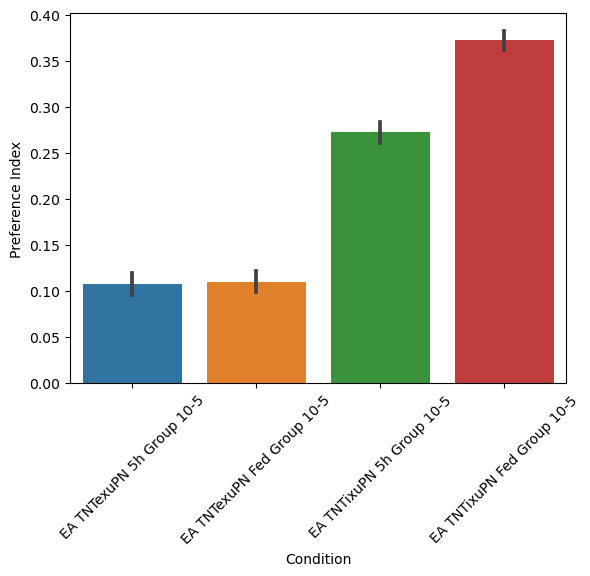

In [ ]:
# sbs.barplot(data=df_stats_PI[df_stats_PI['Frame'] > 400], x = 'Condition', y='Preference Index')
# plt.xticks(rotation = 45)